# Notebook 01: Data verification and exploratory data analysis

Verifies the on-disk structure of all three datasets and produces the EDA every later notebook depends on. Reads, counts, measures, and reports only; it writes no image data and modifies nothing on disk.

## 1. Setup

In [ ]:
# Mount Google Drive if in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

# Locate repository root and append to system path
REPO_ON_DRIVE = "/content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import hashlib
from collections import defaultdict
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import config
from src import splits as SP

importlib.reload(config)
importlib.reload(SP)

config.ensure_output_dirs()
config.summary()


Mounted at /content/drive
Cross-Population CXR Asymmetry Experiment Configuration
-------------------------------------------------------
DATA_ROOT           : /content/drive/MyDrive/MSc AI DISSERTATION/data
Architectures       : ['mobilenet_v2', 'efficientnet_b0']
Directions          : ['K2N', 'N2K']
Matched sizes       : [50, 100, 190]
Class balance       : 1:1 Ratio
Total training runs : 12 (2 archs x 2 dirs x 3 sizes)
CV folds            : 5 | Holdout: 30
Seeds               : [42, 43, 44]


In [ ]:
config.set_all_seeds()
config.set_plot_style()
print("Seeds set to", config.SEED)


Seeds set to 42


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Dataset Structure Verification

In [ ]:
def verify_dataset(name, splits_or_classes, is_split=False):
    """Verify image existence and counts for flat or split datasets."""
    print(f"=== {name} ===")
    rows = []
    splits = splits_or_classes if is_split else {"all": splits_or_classes}

    for split, class_dirs in splits.items():
        split_total = 0
        for cls, d in class_dirs.items():
            imgs = SP.list_images(d)
            ok = Path(d).exists()
            n = len(imgs)
            split_total += n
            rows.append({"dataset": name.lower(), "split": split, "class": cls, "n_images": n, "exists": ok})
            print(f"  {split:6s} {cls:12s} {n:5d}{'' if ok else '  <-- MISSING'}")
        if is_split:
            print(f"  {split:6s} {'(total)':12s} {split_total:5d}")

    return pd.DataFrame(rows)

# Execute Verifications
togunwa_df = verify_dataset("TOGUNWA", config.TOGUNWA_CLASSES, is_split=False)
togunwa_total = togunwa_df["n_images"].sum()

# Togunwa target validations
EXPECTED = {"NORMAL": 93, "PNEUMONIA": 97}
for cls in config.CLASSES:
    actual = int(togunwa_df.loc[togunwa_df["class"] == cls, "n_images"].iloc[0]) if cls in togunwa_df["class"].values else 0
    print(f"  {cls:12s} actual={actual:4d}  {'OK' if actual == EXPECTED[cls] else f'DIFFERS (expected {EXPECTED[cls]})'}")
print(f"  {'TOTAL':12s} actual={togunwa_total:4d}  {'OK' if togunwa_total == 190 else 'DIFFERS (expected 190)'}\n")

kermany_df = verify_dataset("KERMANY", config.KERMANY_SPLITS, is_split=True)
trn = kermany_df[kermany_df.split == "train"]
n_norm = int(trn[trn["class"] == "NORMAL"]["n_images"].iloc[0]) if not trn.empty else 0
n_pneu = int(trn[trn["class"] == "PNEUMONIA"]["n_images"].iloc[0]) if not trn.empty else 0
if n_norm:
    print(f"\nKermany train ratio normal:pneumonia = 1 : {n_pneu / n_norm:.2f}\n")

if config.MUSA_DIR.exists():
    musa_df = verify_dataset("MUSA", config.MUSA_SPLITS, is_split=True)
    present = sorted(config.MUSA_SPLITS["test"].keys())
    print(f"\nClasses present: {present}")
    print("TB and COVID present - OOD analysis supported." if {"TB", "COVID"}.issubset(present)
          else "TB/COVID missing - OOD not supported (core study unaffected).")
else:
    musa_df = pd.DataFrame()
    print("Musa not found. Optional; skipping.")


=== TOGUNWA ===
  all    NORMAL          93
  all    PNEUMONIA       97
  NORMAL       actual=  93  OK
  PNEUMONIA    actual=  97  OK
  TOTAL        actual= 190  OK

=== KERMANY ===
  train  NORMAL        1349
  train  PNEUMONIA     3883
  train  (total)       5232
  test   NORMAL         234
  test   PNEUMONIA      390
  test   (total)        624

Kermany train ratio normal:pneumonia = 1 : 2.88

=== MUSA ===
  train  NORMAL         500
  train  PNEUMONIA      500
  train  TB             500
  train  COVID          500
  train  (total)       2000
  test   NORMAL         150
  test   PNEUMONIA      150
  test   TB             150
  test   COVID          150
  test   (total)        600

Classes present: ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']
TB and COVID present - OOD analysis supported.


## 3. Cross-dataset profiling: formats, colour modes, resolutions

In [ ]:
def gather_dataset_records(name):
    """Retrieve list of (path, class, split) tuples with explicit provenance."""
    records = []
    if name == "togunwa":
        for cls, d in config.TOGUNWA_CLASSES.items():
            for p in SP.list_images(d):
                records.append((p, cls, "all"))
    elif name == "kermany":
        for split, cd in config.KERMANY_SPLITS.items():
            for cls, d in cd.items():
                for p in SP.list_images(d):
                    records.append((p, cls, split))
    elif name == "musa" and config.MUSA_DIR.exists():
        for split, cd in config.MUSA_SPLITS.items():
            for cls, d in cd.items():
                for p in SP.list_images(d):
                    records.append((p, cls, split))
    return records

def profile_images(paths, sample=None):
    if sample and len(paths) > sample:
        import numpy as np
        idx = np.random.choice(len(paths), size=sample, replace=False)
        paths = [paths[i] for i in idx]
    recs = []
    for p in paths:
        try:
            with Image.open(p) as im:
                recs.append({"format": im.format, "width": im.width, "height": im.height, "mode": im.mode, "readable": True})
        except Exception as e:
            recs.append({"readable": False, "error": str(e)})
    return pd.DataFrame(recs)

profiles = {}
# Full profiling enabled across all datasets (set numerical limits e.g., 600/400 to speed up execution if needed)
sampling_limits = {"togunwa": None, "kermany": None, "musa": None}

for name, sample_size in sampling_limits.items():
    records = gather_dataset_records(name)
    paths = [p for p, _, _ in records]
    if not paths:
        continue
    df = profile_images(paths, sample=sample_size)
    profiles[name] = df
    readable = df["readable"].sum()
    r = df[df.readable]
    print(f"=== {name} (full) ===")
    print(f"  readable      : {readable}/{len(df)}")
    print(f"  formats       : {r['format'].value_counts().to_dict()}")
    print(f"  modes         : {r['mode'].value_counts().to_dict()}")
    print(f"  width  (px)   : min={int(r['width'].min())} med={int(r['width'].median())} max={int(r['width'].max())}")
    print(f"  height (px)   : min={int(r['height'].min())} med={int(r['height'].median())} max={int(r['height'].max())}\n")


=== togunwa (full) ===
  readable      : 190/190
  formats       : {'JPEG': 148, 'PNG': 42}
  modes         : {'RGB': 148, 'RGBA': 42}
  width  (px)   : min=700 med=1424 max=2795
  height (px)   : min=589 med=1149 max=2363

=== kermany (full) ===
  readable      : 5856/5856
  formats       : {'JPEG': 5856}
  modes         : {'L': 5573, 'RGB': 283}
  width  (px)   : min=384 med=1281 max=2916
  height (px)   : min=127 med=888 max=2713

=== musa (full) ===
  readable      : 2600/2600
  formats       : {'PNG': 2600}
  modes         : {'L': 1497, 'RGB': 1103}
  width  (px)   : min=299 med=405 max=512
  height (px)   : min=299 med=405 max=512



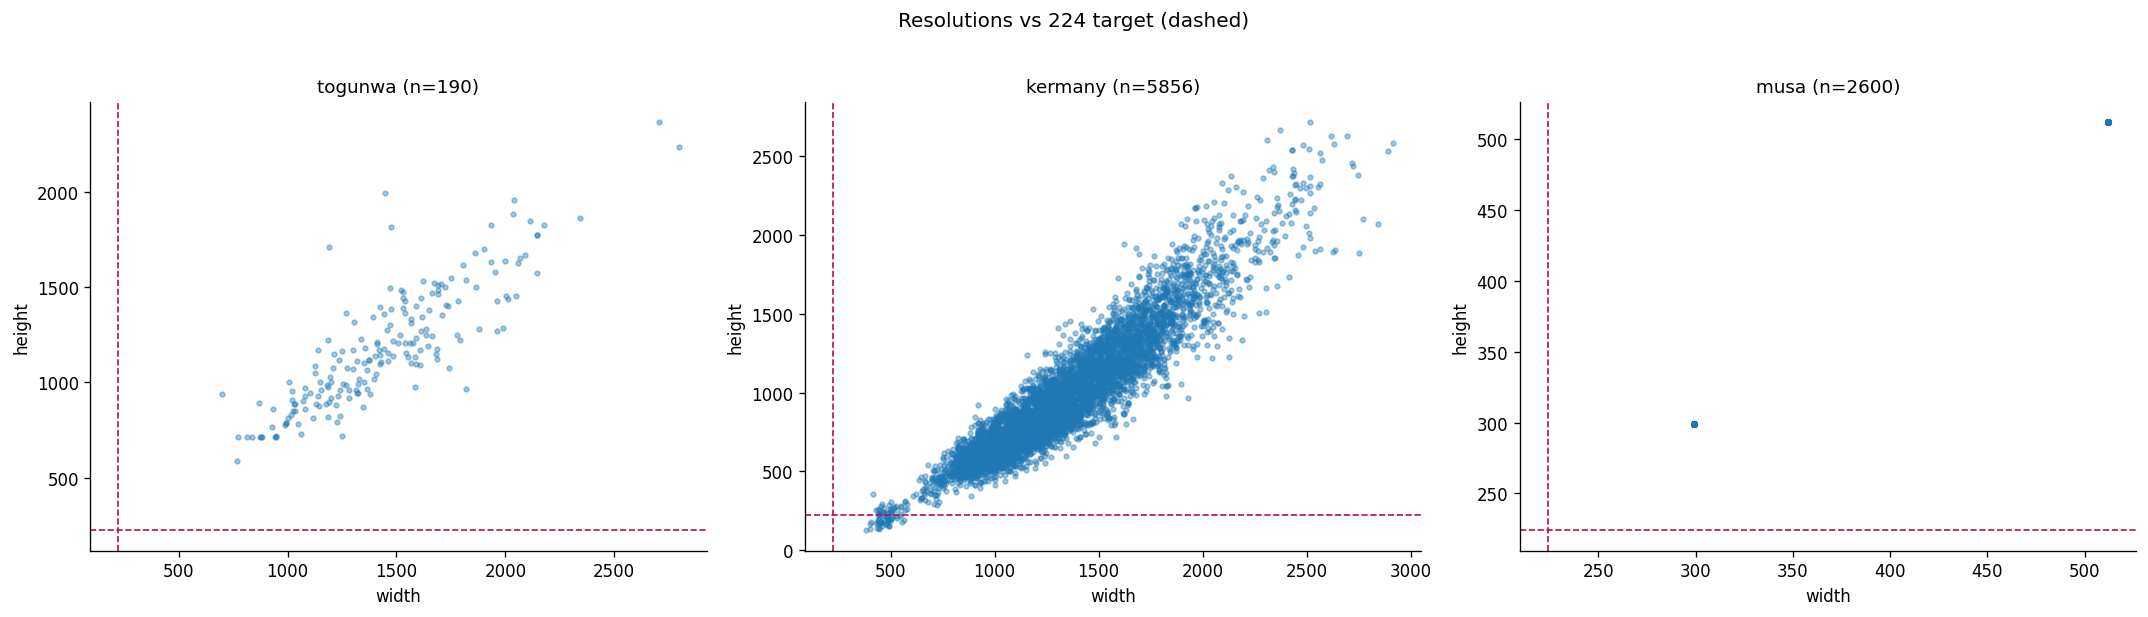

In [ ]:
# Resolution Plotting
fig, axes = plt.subplots(1, len(profiles), figsize=(6 * len(profiles), 5), squeeze=False)
for ax, (name, df) in zip(axes[0], profiles.items()):
    d = df[df.readable]
    ax.scatter(d["width"], d["height"], s=8, alpha=0.4)
    ax.axvline(config.IMAGE_SIZE, color=config.BRAND["C1"], ls="--", lw=1)
    ax.axhline(config.IMAGE_SIZE, color=config.BRAND["C1"], ls="--", lw=1)
    ax.set_title(f"{name} (n={len(d)})")
    ax.set_xlabel("width")
    ax.set_ylabel("height")
fig.suptitle("Resolutions vs 224 target (dashed)", y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "01_resolutions.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# Persist per-dataset profile summaries
prof_rows = []
for name, df in profiles.items():
    d = df[df.readable]
    prof_rows.append({
        "dataset": name,
        "n_profiled": len(d),
        "formats": ", ".join(f"{k}:{v}" for k, v in d["format"].value_counts().items()),
        "modes": ", ".join(f"{k}:{v}" for k, v in d["mode"].value_counts().items()),
        "width_min": int(d["width"].min()), "width_med": int(d["width"].median()), "width_max": int(d["width"].max()),
        "height_min": int(d["height"].min()), "height_med": int(d["height"].median()), "height_max": int(d["height"].max()),
    })
prof_summary = pd.DataFrame(prof_rows)
prof_path = config.RESULTS_DIR / "01_image_profiles.csv"
prof_summary.to_csv(prof_path, index=False)
print(f"Saved: {prof_path}")
prof_summary

Saved: /content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry/outputs/results/01_image_profiles.csv


,dataset,n_profiled,formats,modes,width_min,width_med,width_max,height_min,height_med,height_max
0,togunwa,190,"JPEG:148, PNG:42","RGB:148, RGBA:42",700,1424,2795,589,1149,2363
1,kermany,5856,JPEG:5856,"L:5573, RGB:283",384,1281,2916,127,888,2713
2,musa,2600,PNG:2600,"L:1497, RGB:1103",299,405,512,299,405,512


## 4. Integrity: unreadable files and duplicates

In [ ]:
def hash_file(path, chunk=1<<16):
    h = hashlib.md5()
    try:
        with open(path, "rb") as f:
            for b in iter(lambda: f.read(chunk), b""):
                h.update(b)
        return h.hexdigest()
    except Exception:
        return None

def duplicate_report(name):
    records = gather_dataset_records(name)
    if not records:
        return None
    by_hash = defaultdict(list)
    unreadable = []

    for p, cls, split in records:
        h = hash_file(p)
        if h is None:
            unreadable.append(str(p))
        else:
            by_hash[h].append((str(p), cls, split))

    dups = {h: v for h, v in by_hash.items() if len(v) > 1}
    # Explicit check over tracked split tuple entries
    cross = [v for v in dups.values() if len({s for _, _, s in v}) > 1]

    print(f"=== {name} === \n  total files      : {len(records)} \n  unreadable       : {len(unreadable)} \n  dup_groups       : {len(dups)} \n  cross-split dups : {len(cross)}  <-- leakage risk if > 0\n")
    return {"name": name, "unreadable": unreadable, "cross": cross}

integrity = {}
for name in ["togunwa", "kermany", "musa"]:
    r = duplicate_report(name)
    if r:
        integrity[name] = r

=== togunwa === 
  total files      : 190 
  unreadable       : 0 
  dup_groups       : 0 
  cross-split dups : 0  <-- leakage risk if > 0

=== kermany === 
  total files      : 5856 
  unreadable       : 0 
  dup_groups       : 27 
  cross-split dups : 0  <-- leakage risk if > 0

=== musa === 
  total files      : 2600 
  unreadable       : 0 
  dup_groups       : 13 
  cross-split dups : 0  <-- leakage risk if > 0



## 5. Save summaries and go/no-go

In [ ]:
frames = [df for df in [togunwa_df, kermany_df, musa_df] if not df.empty]
counts = pd.concat(frames, ignore_index=True)[["dataset", "split", "class", "n_images"]]
counts.to_csv(config.RESULTS_DIR / "01_dataset_counts.csv", index=False)
print("Saved 01_dataset_counts.csv")
counts

Saved 01_dataset_counts.csv


,dataset,split,class,n_images
0,togunwa,all,NORMAL,93
1,togunwa,all,PNEUMONIA,97
2,kermany,train,NORMAL,1349
3,kermany,train,PNEUMONIA,3883
4,kermany,test,NORMAL,234
5,kermany,test,PNEUMONIA,390
6,musa,train,NORMAL,500
7,musa,train,PNEUMONIA,500
8,musa,train,TB,500
9,musa,train,COVID,500


In [ ]:
tn = int(togunwa_df.loc[togunwa_df["class"] == "NORMAL", "n_images"].iloc[0]) if "NORMAL" in togunwa_df["class"].values else 0
tp = int(togunwa_df.loc[togunwa_df["class"] == "PNEUMONIA", "n_images"].iloc[0]) if "PNEUMONIA" in togunwa_df["class"].values else 0

checks = [
    ("Togunwa total is 190", togunwa_total == 190),
    ("Togunwa roughly balanced", abs(tn - tp) <= 10),
    ("Kermany train >=190 per class", n_norm >= 190 and n_pneu >= 190),
    ("Kermany test present", not kermany_df[kermany_df.split == "test"].empty and kermany_df[kermany_df.split == "test"]["n_images"].sum() > 0)
]

for name, r in integrity.items():
    checks.append((f"{name}: no unreadable", len(r["unreadable"]) == 0))
    checks.append((f"{name}: no cross-split dups", len(r["cross"]) == 0))

print("\nGO / NO-GO for notebook 02")
print("=" * 46)
allok = True
for lbl, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {lbl}")
    allok = allok and ok
print("=" * 46)
print("READY" if allok else "RESOLVE FAILURES FIRST")


GO / NO-GO for notebook 02
  [PASS]  Togunwa total is 190
  [PASS]  Togunwa roughly balanced
  [PASS]  Kermany train >=190 per class
  [PASS]  Kermany test present
  [PASS]  togunwa: no unreadable
  [PASS]  togunwa: no cross-split dups
  [PASS]  kermany: no unreadable
  [PASS]  kermany: no cross-split dups
  [PASS]  musa: no unreadable
  [PASS]  musa: no cross-split dups
READY


**Next:** notebook 02 builds the splits and balanced downsamples as manifests.